### OSTEOPOROSIS

a medical condition where bones become thin, weak, and porous, making them much more likely to break.

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting 
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder,StandardScaler

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

#Evaluation Metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("osteoporosis.csv")
df

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953,106130,19,Female,Normal,Yes,African American,Normal,Adequate,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,NaN,Yes,0
1954,106463,23,Female,Postmenopausal,Yes,Caucasian,Underweight,Low,Insufficient,Active,No,NaN,NaN,Corticosteroids,No,0
1955,103142,34,Female,Postmenopausal,No,African American,Underweight,Low,Sufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,No,0
1956,105187,25,Male,Postmenopausal,No,African American,Normal,Low,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,0


### DATA UNDERSTANDING

In [3]:
df.tail()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
1953,106130,19,Female,Normal,Yes,African American,Normal,Adequate,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,NaN,Yes,0
1954,106463,23,Female,Postmenopausal,Yes,Caucasian,Underweight,Low,Insufficient,Active,No,NaN,NaN,Corticosteroids,No,0
1955,103142,34,Female,Postmenopausal,No,African American,Underweight,Low,Sufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,No,0
1956,105187,25,Male,Postmenopausal,No,African American,Normal,Low,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,0
1957,108561,26,Female,Postmenopausal,No,African American,Underweight,Adequate,Sufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,0


In [4]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [5]:
df.shape

(1958, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64 
dtypes: int

Statistical Summary

In [7]:
df.describe()

,Id,Age,Osteoporosis
count,1958.000000,1958.000000,1958.000000
mean,105515.320735,39.101124,0.500000
std,2589.407806,21.355424,0.500128
min,101008.000000,18.000000,0.000000
25%,103348.500000,21.000000,0.000000
50%,105469.000000,32.000000,0.500000
75%,107755.000000,53.000000,1.000000
max,109996.000000,90.000000,1.000000


In [8]:
df.dtypes

Id                      int64
Age                     int64
Gender                 object
Hormonal Changes       object
Family History         object
Race/Ethnicity         object
Body Weight            object
Calcium Intake         object
Vitamin D Intake       object
Physical Activity      object
Smoking                object
Alcohol Consumption    object
Medical Conditions     object
Medications            object
Prior Fractures        object
Osteoporosis            int64
dtype: object

In [9]:
df.nunique()

Id                     1749
Age                      73
Gender                    2
Hormonal Changes          2
Family History            2
Race/Ethnicity            3
Body Weight               2
Calcium Intake            2
Vitamin D Intake          2
Physical Activity         2
Smoking                   2
Alcohol Consumption       1
Medical Conditions        2
Medications               1
Prior Fractures           2
Osteoporosis              2
dtype: int64

Identify Numerical and Categorical Columns

In [10]:
numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_columns = df.select_dtypes(
    include=['object']
).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Id', 'Age', 'Osteoporosis']

Categorical Columns:
['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']


## DATA CLEANING

#### Check Missing Values

In [11]:
df.isnull().sum()

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  0
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

#### Check Duplicate Values

In [12]:
#Drop Id column
df=df.drop('Id',axis=1)

In [13]:
df.duplicated().sum()

np.int64(4)

In [14]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print("Total duplicate rows found:", len(duplicates))
display(duplicates)

Total duplicate rows found: 8


,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
1238,18,Female,Normal,No,Asian,Normal,Low,Insufficient,Active,No,Moderate,NaN,NaN,Yes,0
1925,18,Female,Normal,No,Asian,Normal,Low,Insufficient,Active,No,Moderate,NaN,NaN,Yes,0
1032,19,Female,Postmenopausal,Yes,Asian,Underweight,Adequate,Insufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,No,0
1820,19,Female,Postmenopausal,Yes,Asian,Underweight,Adequate,Insufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,No,0
1301,29,Female,Normal,No,Asian,Underweight,Adequate,Sufficient,Sedentary,No,Moderate,NaN,Corticosteroids,No,0
1712,29,Female,Normal,No,Asian,Underweight,Adequate,Sufficient,Sedentary,No,Moderate,NaN,Corticosteroids,No,0
1231,34,Male,Normal,Yes,Caucasian,Underweight,Low,Sufficient,Sedentary,No,Moderate,Hyperthyroidism,Corticosteroids,No,0
1882,34,Male,Normal,Yes,Caucasian,Underweight,Low,Sufficient,Sedentary,No,Moderate,Hyperthyroidism,Corticosteroids,No,0


In [15]:
df = df.drop_duplicates().reset_index(drop=True)

In [16]:
print("Final dataset shape:", df.shape)

Final dataset shape: (1954, 15)


In [17]:
df['Osteoporosis'].value_counts()

Osteoporosis
1    979
0    975
Name: count, dtype: int64

In [18]:
df.columns

Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

In [19]:
print(df["Alcohol Consumption"].isna().sum())

988


In [20]:
df["Alcohol Consumption"].value_counts()

Alcohol Consumption
Moderate    966
Name: count, dtype: int64

In [21]:
print(df["Alcohol Consumption"].unique())

['Moderate' nan]


In [22]:
print(df["Alcohol Consumption"].value_counts(dropna=False))

Alcohol Consumption
NaN         988
Moderate    966
Name: count, dtype: int64


Handle Missing values

In [23]:
df["Alcohol Consumption"] = df["Alcohol Consumption"].fillna("Unknown")
df["Medical Conditions"]=df["Medical Conditions"].fillna("Unknown")
df["Medications"]=df["Medications"].fillna("Unknown")

In [24]:
print(df["Alcohol Consumption"].isna().sum())
print(df["Medical Conditions"].isna().sum())
print(df["Medications"].isna().sum())

0
0
0


In [25]:
print("Missing values count after imputation:")
print(df.isnull().sum())

Missing values count after imputation:
Age                    0
Gender                 0
Hormonal Changes       0
Family History         0
Race/Ethnicity         0
Body Weight            0
Calcium Intake         0
Vitamin D Intake       0
Physical Activity      0
Smoking                0
Alcohol Consumption    0
Medical Conditions     0
Medications            0
Prior Fractures        0
Osteoporosis           0
dtype: int64


In [26]:
for i in df.columns:
    print(df[i].value_counts())

Age
18    151
19    146
34    120
21    117
29    117
     ... 
88      9
60      8
28      8
58      7
48      6
Name: count, Length: 73, dtype: int64
Gender
Male      991
Female    963
Name: count, dtype: int64
Hormonal Changes
Normal            978
Postmenopausal    976
Name: count, dtype: int64
Family History
No     996
Yes    958
Name: count, dtype: int64
Race/Ethnicity
African American    681
Caucasian           645
Asian               628
Name: count, dtype: int64
Body Weight
Normal         1026
Underweight     928
Name: count, dtype: int64
Calcium Intake
Low         1002
Adequate     952
Name: count, dtype: int64
Vitamin D Intake
Sufficient      1009
Insufficient     945
Name: count, dtype: int64
Physical Activity
Active       1019
Sedentary     935
Name: count, dtype: int64
Smoking
Yes    981
No     973
Name: count, dtype: int64
Alcohol Consumption
Unknown     988
Moderate    966
Name: count, dtype: int64
Medical Conditions
Hyperthyroidism         676
Unknown                 6

Checking Outliers

In [27]:
for col in df.select_dtypes(include=['int64','float64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

Age: 0 outliers
Osteoporosis: 0 outliers


### EDA

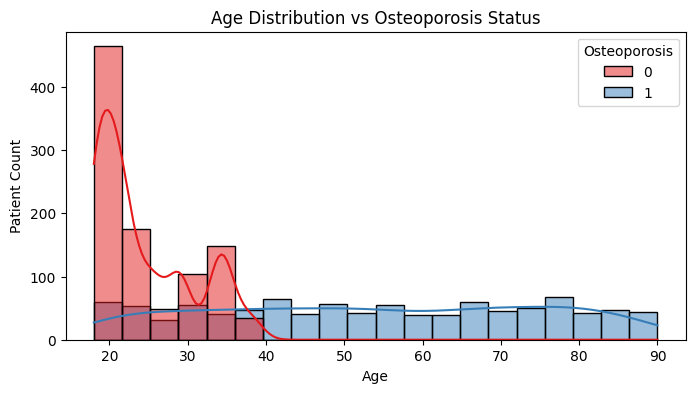

In [28]:

plt. figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Osteoporosis', kde=True, bins=20, palette='Set1')
plt. title('Age Distribution vs Osteoporosis Status')
plt.xlabel('Age')
plt.ylabel('Patient Count')
plt. show()

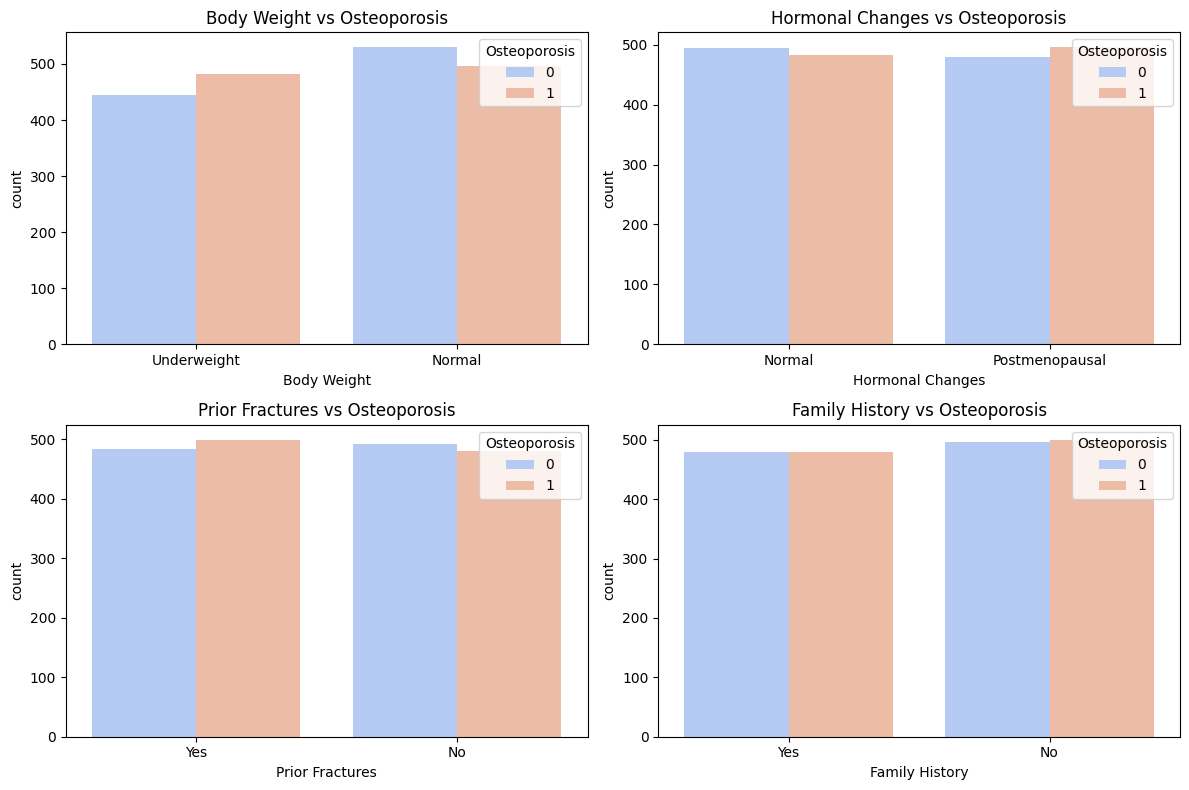

In [29]:
#Ploting categorical Columns
cols_to_plot = [
    'Body Weight',
    'Hormonal Changes',
    'Prior Fractures',
    'Family History'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx // 2, idx % 2]

    sns.countplot(
        data=df,
        x=col,
        hue='Osteoporosis',
        ax=ax,
        palette='coolwarm'
    )

    ax.set_title(f'{col} vs Osteoporosis')

plt.tight_layout()
plt.show()

body Weight vs Osteoporosis:Underweight individuals show a slightly higher prevalence of Osteoporosis () compared to non-affected individuals (). Individuals with normal body weight have a higher proportion of non-affected cases (). This indicates that lower body weight may present a slightly higher risk factor for bone density loss.

Hormonal Changes vs Osteoporosis:Patients in the Postmenopausal group exhibit a higher proportion of Osteoporosis cases () compared to non-affected cases (). Patients with Normal hormonal status show the opposite trend, with slightly more non-affected cases ().

Prior Fractures vs Osteoporosis:Patients with a history of prior fractures (Yes) have a slightly higher count of Osteoporosis cases (). Patients with no prior fractures (No) have a slightly higher proportion of non-affected individuals ().

Family History vs Osteoporosis:Distribution across both categories (Yes / No) is fairly balanced, showing almost equal proportions of affected () and non-affected () patients. This suggests that family history alone shows a very subtle linear relationship with the target variable in this specific subset. 

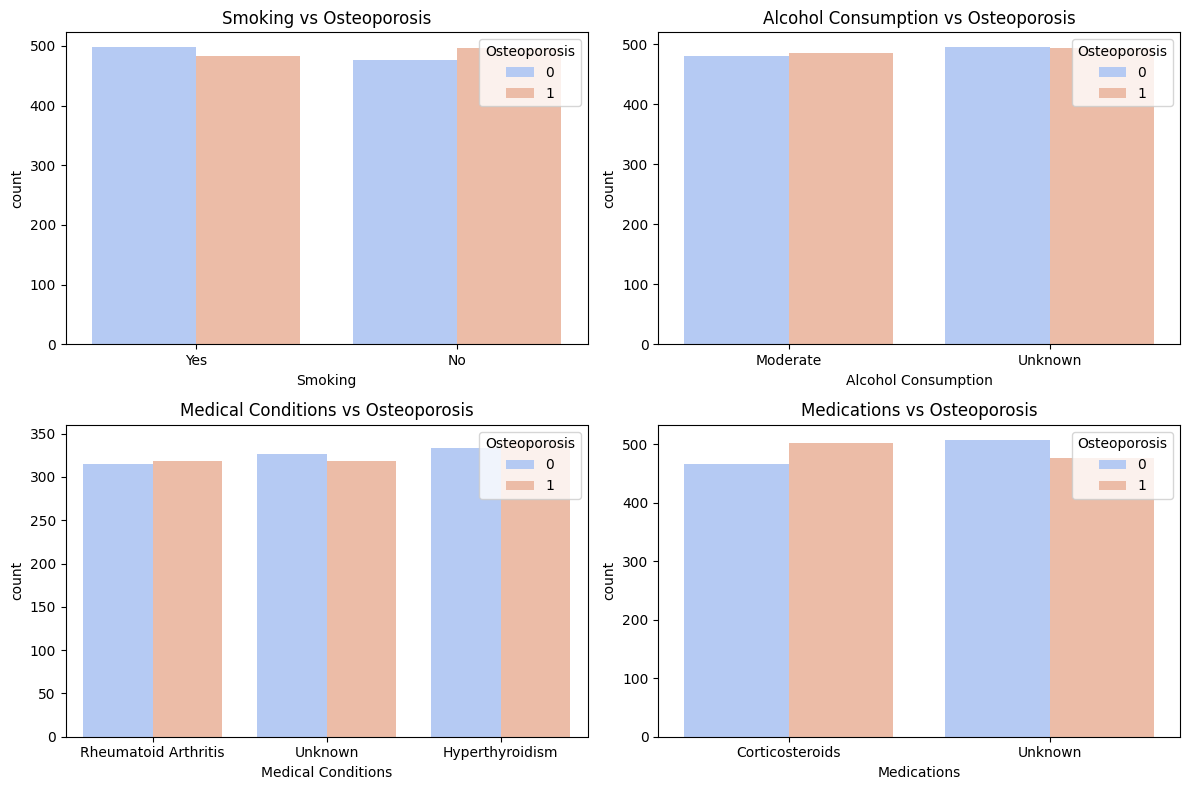

In [30]:
cols_to_plot = [
    'Smoking',
    'Alcohol Consumption',
    'Medical Conditions',
    'Medications'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx // 2, idx % 2]

    sns.countplot(
        data=df,
        x=col,
        hue='Osteoporosis',
        ax=ax,
        palette='coolwarm'
    )

    ax.set_title(f'{col} vs Osteoporosis')

plt.tight_layout()
plt.show()

Smoking vs Osteoporosis:Patients who report No for smoking show a slightly higher count of Osteoporosis cases ($1$) than non-affected cases ($0$).Active smokers (Yes) show a slightly higher proportion of non-affected cases ($0$).

Alcohol Consumption vs Osteoporosis:Both Moderate and None groups have nearly identical totals, with Osteoporosis cases ($1$) slightly exceeding non-affected cases ($0$) in the Moderate consumption group, whereas cases are nearly equal in the None group.

Medical Conditions vs Osteoporosis:Patients with Rheumatoid Arthritis show a slightly higher count of positive Osteoporosis cases ($1$) compared to negative cases ($0$).Patients with Hyperthyroidism have a visibly higher count of non-affected cases ($0$) compared to positive cases ($1$).The None category shows a slightly higher proportion of non-affected cases ($0$).

Medications vs Osteoporosis:Patients taking Corticosteroids show a higher count of Osteoporosis cases ($1$) relative to non-affected cases ($0$).Patients taking None (no specific medications) have a higher count of non-affected cases ($0$) than positive cases ($1$).

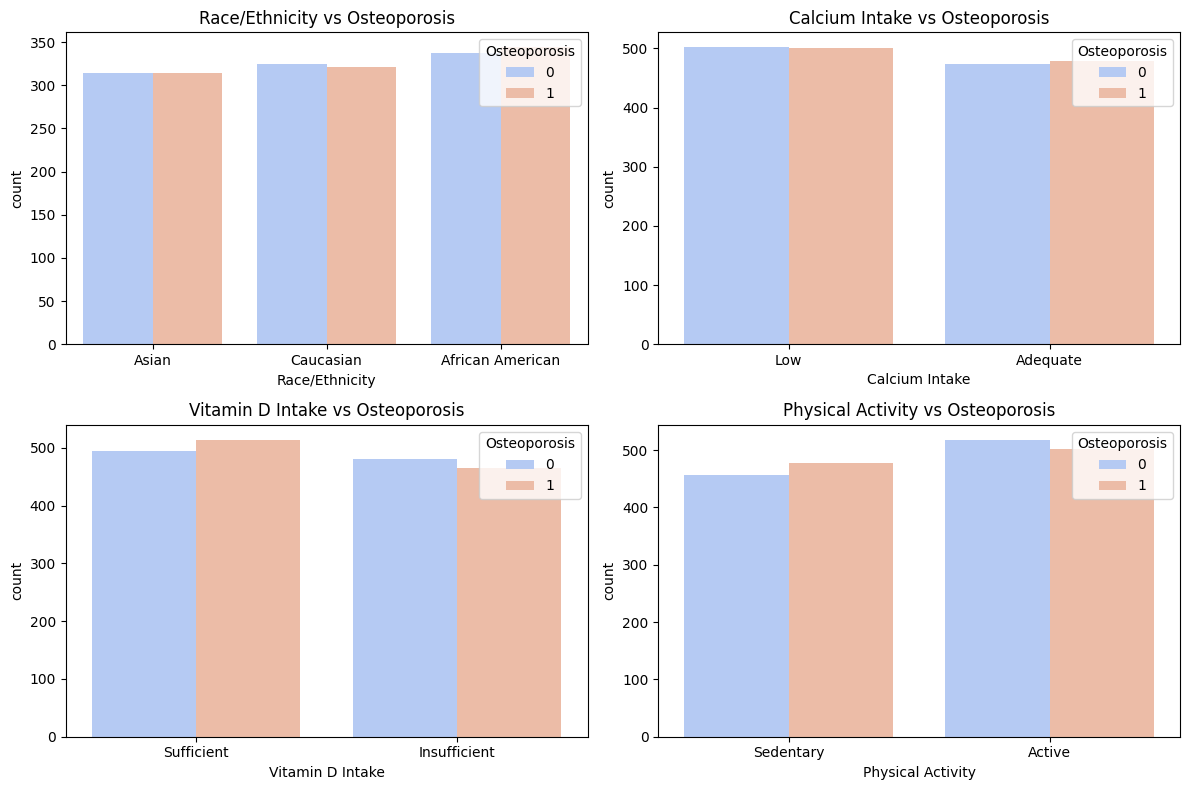

In [31]:
cols_to_plot = [
'Race/Ethnicity',
'Calcium Intake',
'Vitamin D Intake',
'Physical Activity'

]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx // 2, idx % 2]

    sns.countplot(
        data=df,
        x=col,
        hue='Osteoporosis',
        ax=ax,
        palette='coolwarm'
    )

    ax.set_title(f'{col} vs Osteoporosis')

plt.tight_layout()
plt.show()

Race/Ethnicity vs Osteoporosis:

        Across all three groups (Asian, Caucasian, and African American), the proportions of positive Osteoporosis cases (1) and non-affected cases (0) are almost identical. This indicates that ethnicity shows very little direct variance in disease prevalence within this dataset.   
        

Calcium Intake vs Osteoporosis:

        In the Low intake group, the count of non-affected cases (0) and positive cases (1) is perfectly equal.   
    

        In the Adequate intake group, positive cases (1) are slightly higher than non-affected cases (0).   
        PNG

Vitamin D Intake vs Osteoporosis:

        Patients in the Sufficient group show a slightly higher count of positive Osteoporosis cases (1) compared to negative cases (0).   
        PNG

        Patients in the Insufficient group show a slightly higher proportion of non-affected cases (0).   
        PNG

 Physical Activity vs Osteoporosis:

        Individuals with a Sedentary lifestyle show a higher count of Osteoporosis cases (1) relative to non-affected cases (0).   
        PNG

        Individuals categorized as Active have a higher proportion of non-affected cases (0) than positive cases (1), suggesting regular physical activity is associated with a lower disease incidence.   
        PNG

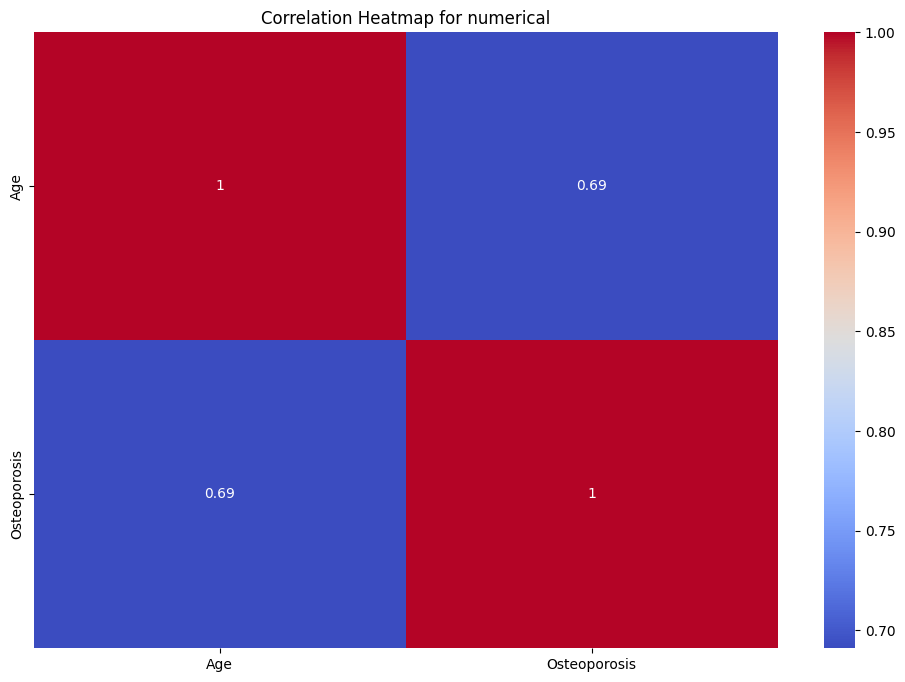

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for numerical")
plt.show()

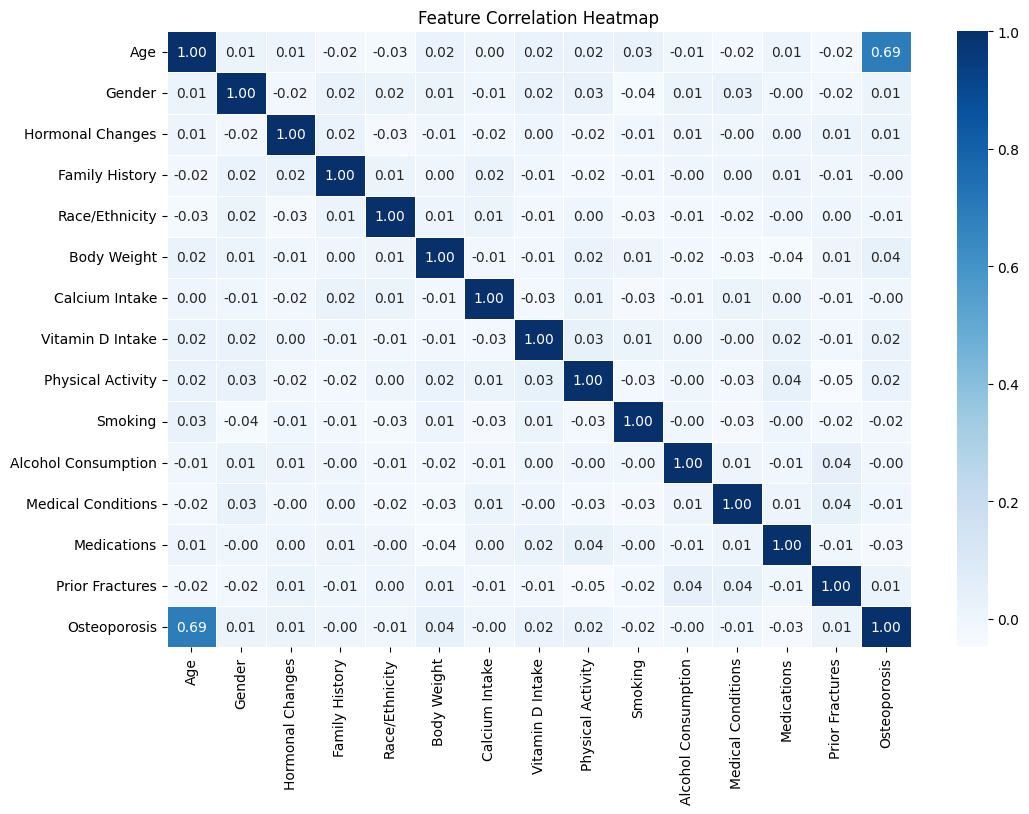

In [33]:
import numpy as np

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [34]:
#Histograms for All Numerical Columns
#df.hist(figsize=(9,6))
#plt.suptitle("Histogram of Age & Osteoporosis")
#plt.show()

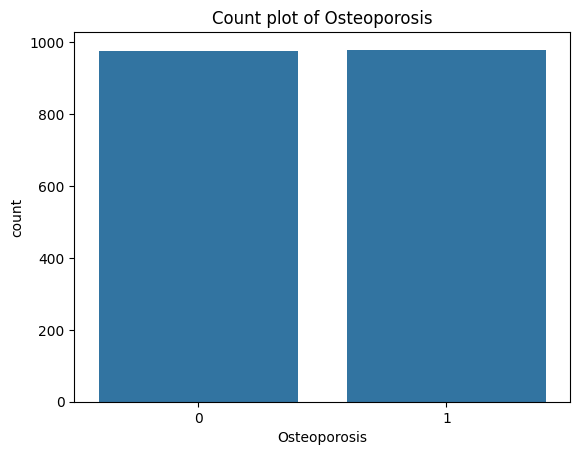

In [35]:
#COUNT PLOT
sns.countplot(x='Osteoporosis', data=df)
plt.title("Count plot of Osteoporosis")
plt.show()

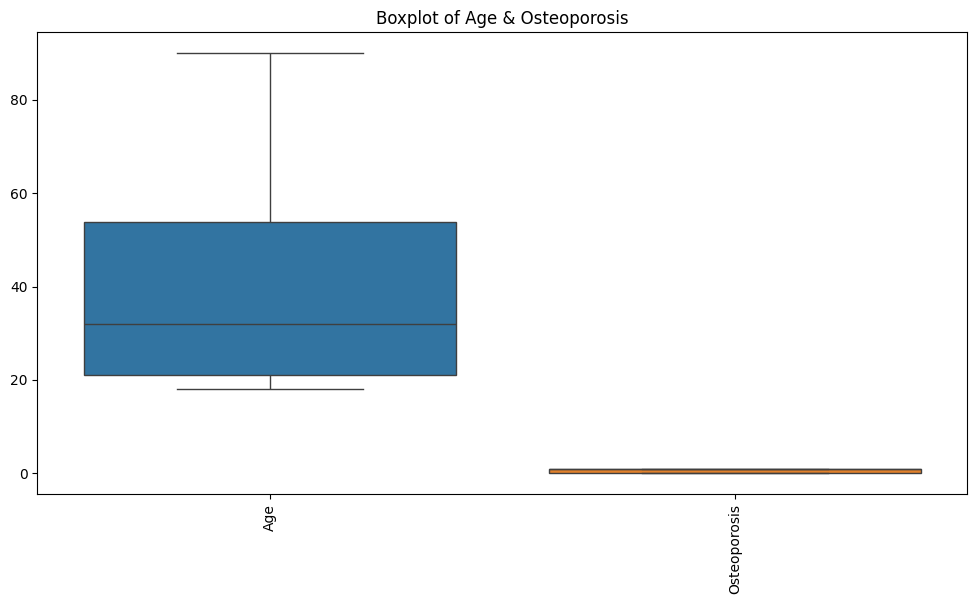

In [36]:
#Boxplots for All Numerical Columns
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Age & Osteoporosis")
plt.show()

Checking Outliers for Age columns

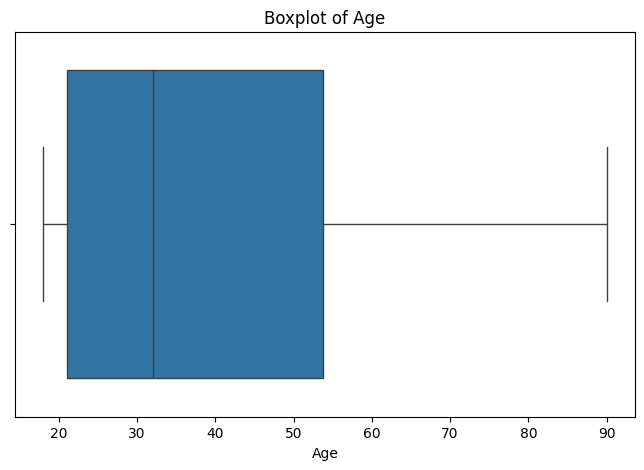

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Age'])

plt.title('Boxplot of Age')
plt.xlabel('Age')

plt.show()

In [38]:
# Calculate Q1 and Q3
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = df[
    (df['Age'] < lower_bound) |
    (df['Age'] > upper_bound)
]

print("\nNumber of outliers:", len(outliers))

print("\nOutlier records:")
print(outliers[['Age']])

Q1: 21.0
Q3: 53.75
IQR: 32.75
Lower Bound: -28.125
Upper Bound: 102.875

Number of outliers: 0

Outlier records:
Empty DataFrame
Columns: [Age]
Index: []


### ENCODING

In [39]:
df.columns

Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

In [40]:
columns=['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures']
for col in columns:
    print(f"\nColumn:'{col}")
    print(df[col].unique())


Column:'Gender
['Female' 'Male']

Column:'Hormonal Changes
['Normal' 'Postmenopausal']

Column:'Family History
['Yes' 'No']

Column:'Race/Ethnicity
['Asian' 'Caucasian' 'African American']

Column:'Body Weight
['Underweight' 'Normal']

Column:'Calcium Intake
['Low' 'Adequate']

Column:'Vitamin D Intake
['Sufficient' 'Insufficient']

Column:'Physical Activity
['Sedentary' 'Active']

Column:'Smoking
['Yes' 'No']

Column:'Alcohol Consumption
['Moderate' 'Unknown']

Column:'Medical Conditions
['Rheumatoid Arthritis' 'Unknown' 'Hyperthyroidism']

Column:'Medications
['Corticosteroids' 'Unknown']

Column:'Prior Fractures
['Yes' 'No']


In [41]:
df_encoded = df.copy()

# Manual Mapping for Binary Columns

binary_mappings = {
    'Gender': {'Female': 1, 'Male': 0},
    'Hormonal Changes': {'Postmenopausal': 1, 'Normal': 0},
    'Family History': {'Yes': 1, 'No': 0},
    'Body Weight': {'Underweight': 1, 'Normal': 0},
    'Calcium Intake': {'Adequate': 1, 'Low': 0},
    'Vitamin D Intake': {'Sufficient': 1, 'Insufficient': 0},
    'Physical Activity': {'Active': 1, 'Sedentary': 0},
    'Smoking': {'Yes': 1, 'No': 0},
    'Alcohol Consumption': {'Moderate': 1, 'Unknown': 0},
    'Medications': {'Corticosteroids': 1, 'Unknown': 0},
    'Prior Fractures': {'Yes': 1, 'No': 0}
}

for col, mapping in binary_mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)


In [42]:
# One hot Encoding for Multi-Clas Columns
multi_class_cols=['Race/Ethnicity','Medical Conditions']
df_encoded= pd.get_dummies(df_encoded,columns=multi_class_cols,drop_first=True,dtype=int)

In [43]:
print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (1954, 17)


,Age,Gender,Hormonal Changes,Family History,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medications,Prior Fractures,Osteoporosis,Race/Ethnicity_Asian,Race/Ethnicity_Caucasian,Medical Conditions_Rheumatoid Arthritis,Medical Conditions_Unknown
0,69,1,0,1,1,0,1,0,1,1,1,1,1,1,0,1,0
1,32,1,0,1,1,0,1,0,0,0,0,1,1,1,0,0,1
2,89,1,1,0,0,1,1,1,0,1,1,0,1,0,1,0,0
3,78,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0
4,38,0,1,1,0,0,1,1,1,0,0,1,1,0,0,1,0


In [44]:
print("Encoded dataset shape:",df_encoded.shape)
df_encoded.head()


Encoded dataset shape: (1954, 17)


,Age,Gender,Hormonal Changes,Family History,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medications,Prior Fractures,Osteoporosis,Race/Ethnicity_Asian,Race/Ethnicity_Caucasian,Medical Conditions_Rheumatoid Arthritis,Medical Conditions_Unknown
0,69,1,0,1,1,0,1,0,1,1,1,1,1,1,0,1,0
1,32,1,0,1,1,0,1,0,0,0,0,1,1,1,0,0,1
2,89,1,1,0,0,1,1,1,0,1,1,0,1,0,1,0,0
3,78,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0
4,38,0,1,1,0,0,1,1,1,0,0,1,1,0,0,1,0


In [45]:
df_encoded.isna().sum()

Age                                        0
Gender                                     0
Hormonal Changes                           0
Family History                             0
Body Weight                                0
Calcium Intake                             0
Vitamin D Intake                           0
Physical Activity                          0
Smoking                                    0
Alcohol Consumption                        0
Medications                                0
Prior Fractures                            0
Osteoporosis                               0
Race/Ethnicity_Asian                       0
Race/Ethnicity_Caucasian                   0
Medical Conditions_Rheumatoid Arthritis    0
Medical Conditions_Unknown                 0
dtype: int64

### XY SEPARATION

In [46]:
print(df_encoded.columns.to_list())

['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medications', 'Prior Fractures', 'Osteoporosis', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Caucasian', 'Medical Conditions_Rheumatoid Arthritis', 'Medical Conditions_Unknown']


In [47]:
df_encoded.shape

(1954, 17)

In [48]:
X=df_encoded.drop("Osteoporosis",axis=1)
y=df_encoded["Osteoporosis"]

In [49]:
X

,Age,Gender,Hormonal Changes,Family History,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medications,Prior Fractures,Race/Ethnicity_Asian,Race/Ethnicity_Caucasian,Medical Conditions_Rheumatoid Arthritis,Medical Conditions_Unknown
0,69,1,0,1,1,0,1,0,1,1,1,1,1,0,1,0
1,32,1,0,1,1,0,1,0,0,0,0,1,1,0,0,1
2,89,1,1,0,0,1,1,1,0,1,1,0,0,1,0,0
3,78,1,0,0,1,1,0,0,1,0,1,0,0,1,1,0
4,38,0,1,1,0,0,1,1,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,19,1,0,1,0,1,1,0,1,1,0,1,0,0,1,0
1950,23,1,1,1,1,0,0,1,0,0,1,0,0,1,0,1
1951,34,1,1,0,1,0,1,0,0,0,0,0,0,0,0,0
1952,25,0,1,0,0,0,0,0,1,0,1,1,0,0,1,0


In [50]:
y

0       1
1       1
2       1
3       1
4       1
       ..
1949    0
1950    0
1951    0
1952    0
1953    0
Name: Osteoporosis, Length: 1954, dtype: int64

TRAIN TEST SPLIT

In [51]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

Standered Scaler

In [52]:
scaler = StandardScaler()
X_train['Age'] = scaler.fit_transform(X_train[['Age']])
X_test['Age'] = scaler.transform(X_test[['Age']])

In [53]:
print(y_train.value_counts())

Osteoporosis
1    783
0    780
Name: count, dtype: int64


#### 1.Logistic Regression

In [54]:
lr =LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [56]:
lrt=accuracy_score(y_test,y_test_pred)*100
lrr=accuracy_score(y_train,y_train_pred)*100
print("Test Accuracy:",lrt)
print("Train Accuracy:",lrr)

Test Accuracy: 80.30690537084399
Train Accuracy: 83.42930262316058



Confusion Matrix:


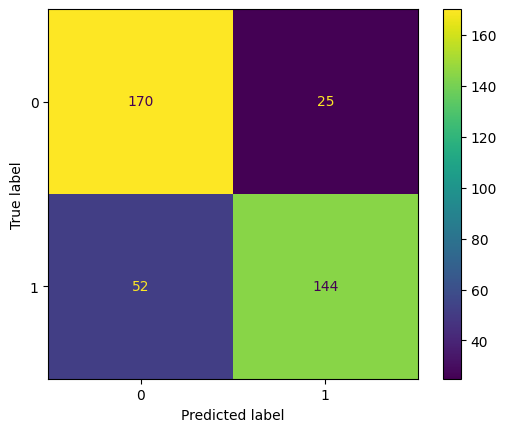

In [57]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

In [58]:
print("\nClassification Report")
print(classification_report(y_test,y_test_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       195
           1       0.85      0.73      0.79       196

    accuracy                           0.80       391
   macro avg       0.81      0.80      0.80       391
weighted avg       0.81      0.80      0.80       391



#### 2.Decision Tree Classifier

In [59]:
dt=DecisionTreeClassifier(max_depth=6, 
random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [60]:
y_train_pred_dt=dt.predict(X_train)
y_test_pred_dt=dt.predict(X_test)

In [61]:
#print("Test Score:",dt.score(X_test,y_test_pred))
#print("Train Score:",dt.score(X_train,y_train_pred))

In [62]:
dtr=accuracy_score(y_train,y_train_pred_dt)*100
dtt=accuracy_score(y_test,y_test_pred_dt)*100
print("Train Accuracy:",dtr)
print("Test Accuracy:",dtt)

Train Accuracy: 90.72296865003199
Test Accuracy: 86.95652173913044



Confusion Matrix:
[[192   3]
 [ 48 148]]


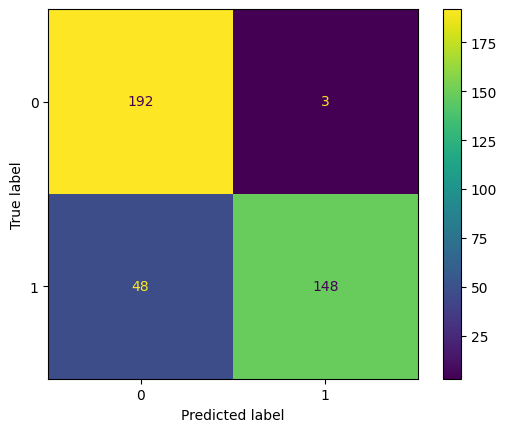

In [63]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_test_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_dt)

In [64]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88       195
           1       0.98      0.76      0.85       196

    accuracy                           0.87       391
   macro avg       0.89      0.87      0.87       391
weighted avg       0.89      0.87      0.87       391



#### 3.Random Forest Classifier

In [65]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=5, random_state=42)

In [66]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

In [67]:
#print("Test Score:",rf.score(X_test,y_test_pred_rf))
#print("Train Score:",rf.score(X_train,y_train_pred_rf))

In [68]:
rfr=accuracy_score(y_train,y_train_pred_rf)*100
rft=accuracy_score(y_test,y_test_pred_rf)*100
print("RF Train Accuracy:",rfr)
print("RF Test Accuracy:",rft)

RF Train Accuracy: 87.39603326935381
RF Test Accuracy: 84.14322250639387



Confusion Matrix:
[[194   1]
 [ 61 135]]


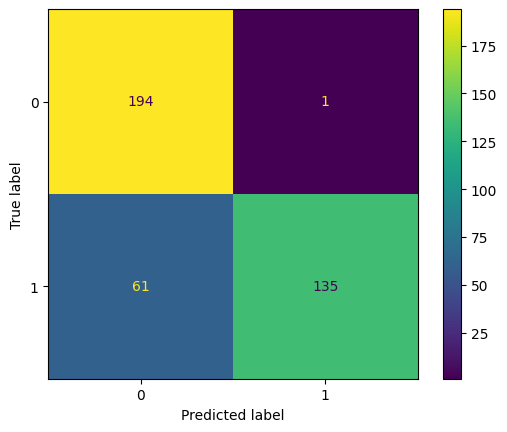

In [69]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_test_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf)

In [70]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       195
           1       0.99      0.69      0.81       196

    accuracy                           0.84       391
   macro avg       0.88      0.84      0.84       391
weighted avg       0.88      0.84      0.84       391



### 4.KNN

In [71]:
knn=KNeighborsClassifier(
n_neighbors=15
)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=15)

In [72]:
y_train_pred_knn=knn.predict(X_train)
y_test_pred_knn=knn.predict(X_test)

In [73]:
#print("Test Score:",knn.score(X_test,y_test_pred))
#print("Train Score:",knn.score(X_train,y_train_pred))

In [74]:
knnr=accuracy_score(y_train,y_train_pred_knn)*100
knnt=accuracy_score(y_test,y_test_pred_knn)*100
print("Train Accuracy Score:",knnr)
print("Test Accuracy Score:",knnt)

Train Accuracy Score: 84.32501599488164
Test Accuracy Score: 79.79539641943734



Confusion Matrix:


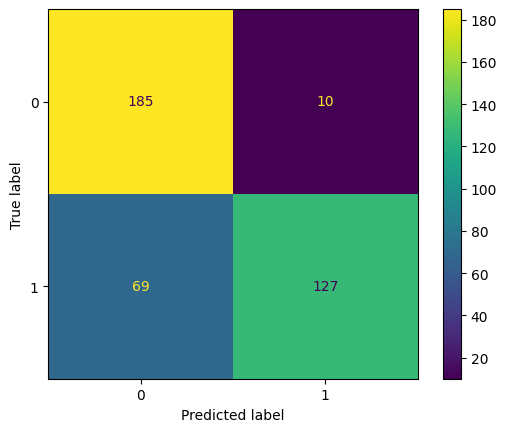

In [75]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn)

In [76]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_knn))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.95      0.82       195
           1       0.93      0.65      0.76       196

    accuracy                           0.80       391
   macro avg       0.83      0.80      0.79       391
weighted avg       0.83      0.80      0.79       391



### 5.SVM

In [77]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42,
    probability=True
)
svm.fit(X_train,y_train)

SVC(probability=True, random_state=42)

In [78]:
y_train_pred_svc = svm.predict(X_train)
y_test_pred_svc = svm.predict( X_test)

In [79]:
#print("Test Score:",knn.score(X_test,y_test_pred))
#print("Train Score:",knn.score(X_train,y_train_pred))

In [80]:
svcr=accuracy_score(y_train,y_train_pred_svc)*100
svct=accuracy_score( y_test, y_test_pred_svc)*100
print("SVM Train Accuracy:",svcr)
print("SVM Test Accuracy:",svct)

SVM Train Accuracy: 88.16378758797185
SVM Test Accuracy: 82.09718670076727



Confusion Matrix:


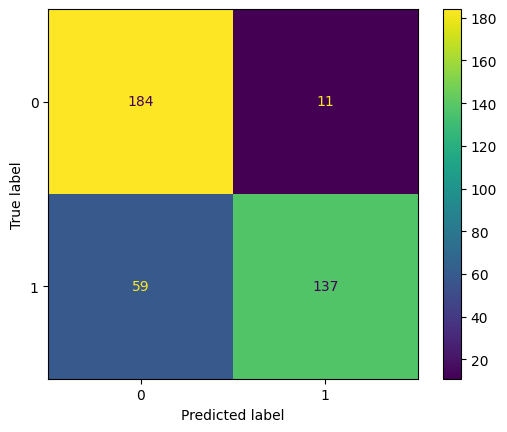

In [81]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svc)

In [82]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       195
           1       0.85      0.73      0.79       196

    accuracy                           0.80       391
   macro avg       0.81      0.80      0.80       391
weighted avg       0.81      0.80      0.80       391



#### 6.Gussian Naive Bayes(GNB)

In [83]:
nb=GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [84]:
y_train_pred_nb=nb.predict(X_train)
y_test_pred_nb=nb.predict(X_test)

In [85]:
#print("Test Score:",nb.score(X_test,y_test))
#print("Train Score:",nb.score(X_train,y_train))

In [86]:
nbr=accuracy_score(y_train,y_train_pred_nb)*100
nbt=accuracy_score(y_test,y_test_pred_nb)*100
print("Train Accuracy Score:",nbr)
print("Test Accuracy Score:",nbt)

Train Accuracy Score: 86.11644273832374
Test Accuracy Score: 83.63171355498721



Confusion Matrix:


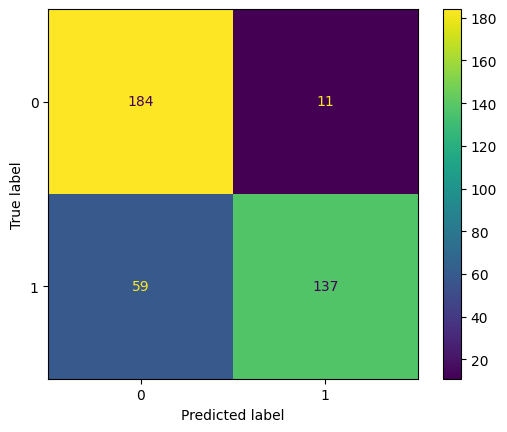

In [87]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svc)

In [88]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_svc))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       195
           1       0.93      0.70      0.80       196

    accuracy                           0.82       391
   macro avg       0.84      0.82      0.82       391
weighted avg       0.84      0.82      0.82       391



#### 7.Gradient Boosting Classifier (GBC)

In [89]:
gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=1,
    random_state=42
)
gbc.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=1, random_state=42)

In [90]:
y_train_pred_gbc = gbc.predict(X_train)
y_test_pred_gbc = gbc.predict(X_test)

In [91]:
gbcr=accuracy_score(y_train, y_train_pred_gbc)* 100
gbct=accuracy_score(y_test, y_test_pred_gbc)* 100
print("GBC Train Accuracy:", gbcr)
print("GBC Test Accuracy:",gbct)

GBC Train Accuracy: 89.31541906589892
GBC Test Accuracy: 86.95652173913044



Confusion Matrix:


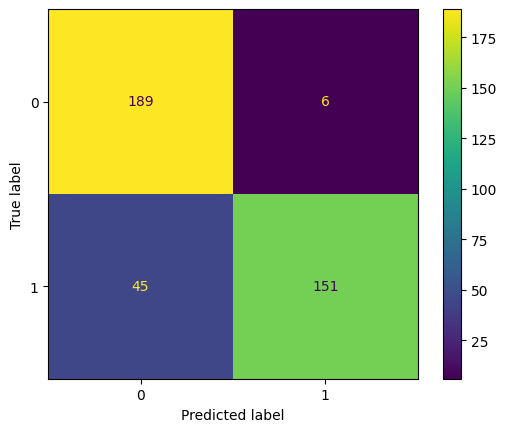

In [92]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_gbc)

In [93]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_gbc))


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       195
           1       0.96      0.77      0.86       196

    accuracy                           0.87       391
   macro avg       0.88      0.87      0.87       391
weighted avg       0.88      0.87      0.87       391



#### 8.AdaBoost Classifier

In [94]:
ada = AdaBoostClassifier(
    n_estimators=100,
    estimator=None,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)


AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [95]:
y_train_pred_ada = ada.predict(X_train)
y_test_pred_ada = ada.predict(X_test)

In [96]:
adar=accuracy_score(y_train, y_train_pred_ada)* 100
adat=accuracy_score(y_test, y_test_pred_ada)* 100
print("AdaBoost Train Accuracy:", adar)
print("AdaBoost Test Accuracy:", adat)

AdaBoost Train Accuracy: 86.30838131797825
AdaBoost Test Accuracy: 83.88746803069054



Confusion Matrix:


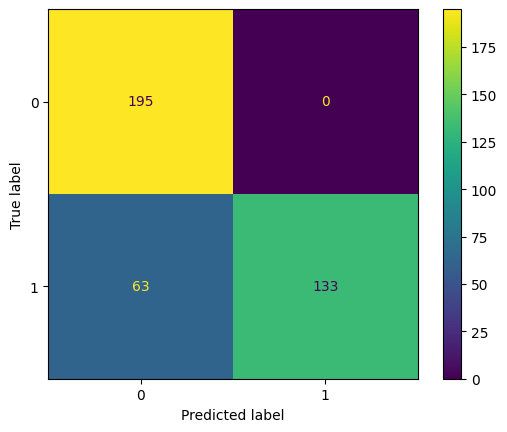

In [97]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_ada)

In [98]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_ada))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       195
           1       1.00      0.68      0.81       196

    accuracy                           0.84       391
   macro avg       0.88      0.84      0.83       391
weighted avg       0.88      0.84      0.83       391



#### 9.XGBoost Classifier

In [99]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [100]:
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

In [101]:
xgbr=accuracy_score(y_train, y_train_pred_xgb)* 100
xgbt=accuracy_score(y_test, y_test_pred_xgb)* 100
print("XGBoost Train Accuracy:",xgbr)
print("XGBoost Test Accuracy:", xgbt)

XGBoost Train Accuracy: 92.13051823416507
XGBoost Test Accuracy: 88.49104859335038



Confusion Matrix:


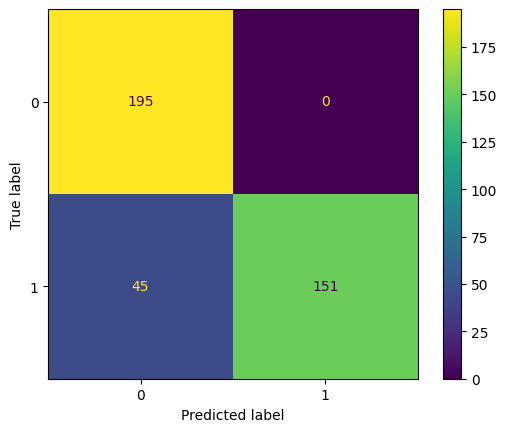

In [102]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_xgb)

In [103]:
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       195
           1       1.00      0.77      0.87       196

    accuracy                           0.88       391
   macro avg       0.91      0.89      0.88       391
weighted avg       0.91      0.88      0.88       391



#### TABLE COMPARISON

In [104]:
tb = pd.DataFrame()
tb['Model'] = pd.Series(
    ['lr','dt','rf','knn','svm','nb','gbc','ada','xgb' ]
)
tb['train_accuracy'] = pd.Series(
    [lrr,dtr,rfr,knnr,svcr,nbr,gbcr,adar,xgbr]
    )
tb['test_accuracy'] = pd.Series([lrt,dtt,rft,knnt,svct,nbt,gbct,adat,xgbt])
tb

,Model,train_accuracy,test_accuracy
0,lr,83.429303,80.306905
1,dt,90.722969,86.956522
2,rf,87.396033,84.143223
3,knn,84.325016,79.795396
4,svm,88.163788,82.097187
5,nb,86.116443,83.631714
6,gbc,89.315419,86.956522
7,ada,86.308381,83.887468
8,xgb,92.130518,88.491049


### HYPER PARAMETER TUNING

In [105]:
print("--- LOGISTIC REGRESSION ---")
lr_params = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {"C": [1, 5, 10], "penalty": ["l1", "l2"], "solver": ["liblinear"]},
    cv=3
)
lr_params.fit(X_train, y_train)

--- LOGISTIC REGRESSION ---


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [1, 5, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']})

In [106]:
dt = DecisionTreeClassifier(random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [3, 5, 7, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    cv=3
)
dt_grid.fit(X_train, y_train_pred)


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [107]:
print("--- RANDOM FOREST ---")
rf_params = {
    "n_estimators": [100, 150],
    "max_depth": [3, 5, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),rf_params,cv=3,n_jobs=-1
)
rf_grid.fit(X_train, y_train)

--- RANDOM FOREST ---


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 8, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150]})

In [108]:
print("--- KNN ---")
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {
        "n_neighbors": [7,11, 15, 21],
        "weights": ["uniform"],
        "metric":['euclidean','manhattan']
    },
    cv=2,
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)

--- KNN ---


GridSearchCV(cv=2, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [7, 11, 15, 21],
                         'weights': ['uniform']})

In [109]:
print("--- SUPPORT VECTOR CLASSIFIER ---")
sv_params = {
    'C': [0.1, 1.0, 5.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
}
sv_grid = GridSearchCV(SVC(random_state=42), sv_params, cv=5, scoring='accuracy', n_jobs=-1)
sv_grid.fit(X_train, y_train)

--- SUPPORT VECTOR CLASSIFIER ---


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1.0, 5.0], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [110]:
print("--- GAUSSIAN NAIVE BAYES ---")
gnb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}
gnb_grid = GridSearchCV(GaussianNB(), gnb_params, cv=5, scoring='accuracy', n_jobs=-1)
gnb_grid.fit(X_train, y_train)

--- GAUSSIAN NAIVE BAYES ---


GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]},
             scoring='accuracy')

In [111]:
print("--- GRADIENT BOOSTING ---")
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 0.9, 1.0]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)

--- GRADIENT BOOSTING ---


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy')

In [112]:
print("--- ADABOOST ---")
ada_params = {
    'n_estimators': [30, 50, 80],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_params, cv=5, scoring='accuracy', n_jobs=-1)
ada_grid.fit(X_train, y_train)

--- ADABOOST ---


GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'n_estimators': [30, 50, 80]},
             scoring='accuracy')

In [113]:
print("--- XGBOOST ---")
xgb_params = {
    'n_estimators': [60, 100],
    'learning_rate': [0.03, 0.08, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.7, 0.8],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1.0, 2.0]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

--- XGBOOST ---


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.08, 0.1],
                         'max_depth': [2, 3], 'n_estimators': [60, 100],
                         'reg_alpha': [0.1, 0.5], 'reg_lambda': [1.0, 2.0],
                         'subsample': [0.7, 0.8]},
             scoring='accuracy')

In [114]:
models = {'Random Forest': rf_grid,'SVM': sv_grid,'Logistic Regression': lr_params,'Decision Tree': dt_grid,'KNN':knn_grid,'GB':gb_grid,'xgb':xgb_grid,'GAUSSIAN NAIVE BAYES':gnb_grid}
for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy: {acc:.4f}\n")

Random Forest:
  Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  Accuracy: 0.8414

SVM:
  Best Params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
  Accuracy: 0.8312

Logistic Regression:
  Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
  Accuracy: 0.8031

Decision Tree:
  Best Params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
  Accuracy: 0.7980

KNN:
  Best Params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
  Accuracy: 0.7980

GB:
  Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
  Accuracy: 0.8824

xgb:
  Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
  Accuracy: 0.8824

GAUSSIAN NAIVE BAYES:
  Best Params: {'var_smoothing': 1e-09}
  Accuracy: 0.8363



# MODEL EVALUATION

In [115]:
# BEFORE vs AFTER HYPERPARAMETER TUNING
before_df = tb.copy()

before_df = before_df.rename(columns={
    "train_accuracy": "Before Train Accuracy (%)",
    "test_accuracy": "Before Test Accuracy (%)"
})

# Model name mapping
before_df["Model"] = before_df["Model"].map({
    "lr": "Logistic Regression",
    "dt": "Decision Tree",
    "rf": "Random Forest",
    "knn": "KNN",
    "svm": "SVM",
    "nb": "Gaussian Naive Bayes",
    "gbc": "Gradient Boosting",
    "ada": "AdaBoost",
    "xgb": "XGBoost"
})

# Tuned models
tuned_models = {
    "Logistic Regression": lr_params,
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "KNN": knn_grid,
    "SVM": sv_grid,
    "Gaussian Naive Bayes": gnb_grid,
    "Gradient Boosting": gb_grid,
    "AdaBoost": ada_grid,
    "XGBoost": xgb_grid
}

# Calculate tuned train and test accuracy
after_results = []

for name, grid in tuned_models.items():

    best_model = grid.best_estimator_

    train_accuracy = accuracy_score(
        y_train,
        best_model.predict(X_train)
    ) * 100

    test_accuracy = accuracy_score(
        y_test,
        best_model.predict(X_test)
    ) * 100

    after_results.append({
        "Model": name,
        "After Train Accuracy (%)": round(train_accuracy, 2),
        "After Test Accuracy (%)": round(test_accuracy, 2)
    })

after_df = pd.DataFrame(after_results)

# Merge before and after results
comparison_df = pd.merge(
    before_df,
    after_df,
    on="Model"
)

# Calculate improvement in test accuracy
comparison_df["Test Accuracy Change (%)"] = (
    comparison_df["After Test Accuracy (%)"]
    - comparison_df["Before Test Accuracy (%)"]
).round(2)

# Arrange columns
comparison_df = comparison_df[
    [
        "Model",
        "Before Train Accuracy (%)",
        "Before Test Accuracy (%)",
        "After Train Accuracy (%)",
        "After Test Accuracy (%)",
        "Test Accuracy Change (%)"
    ]
]

# Sort by after-tuning test accuracy
comparison_df = comparison_df.sort_values(
    by="After Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)
print("=== BEFORE vs AFTER HYPERPARAMETER TUNING ===")
comparison_df


=== BEFORE vs AFTER HYPERPARAMETER TUNING ===


,Model,Before Train Accuracy (%),Before Test Accuracy (%),After Train Accuracy (%),After Test Accuracy (%),Test Accuracy Change (%)
0,Gradient Boosting,89.315419,86.956522,92.26,88.24,1.28
1,XGBoost,92.130518,88.491049,92.32,88.24,-0.25
2,Random Forest,87.396033,84.143223,87.40,84.14,-0.00
3,AdaBoost,86.308381,83.887468,86.31,83.89,0.00
4,Gaussian Naive Bayes,86.116443,83.631714,86.12,83.63,-0.00
5,SVM,88.163788,82.097187,86.12,83.12,1.02
6,Logistic Regression,83.429303,80.306905,83.11,80.31,0.00
7,Decision Tree,90.722969,86.956522,83.49,79.80,-7.16
8,KNN,84.325016,79.795396,84.33,79.80,0.00


In [116]:
ev = pd.DataFrame()
ev['Model'] = pd.Series(
    ['gbc','xgb' ]
)
ev['train_accuracy'] = pd.Series(
    [gbcr,xgbr]
    )
ev['test_accuracy'] = pd.Series([gbct,xgbt])
ev

,Model,train_accuracy,test_accuracy
0,gbc,89.315419,86.956522
1,xgb,92.130518,88.491049


In [117]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix,
    classification_report
)

        GRADIENT BOOSTING EVALUATION        
Mean CV Accuracy   : 0.9213 (±0.0124)
Test Set Accuracy  : 0.8824
Generalization Gap : +0.0390
---------------------------------------------
Recall (Sensitivity): 0.7704
Precision           : 0.9934
F1-Score            : 0.8678
ROC-AUC Score       : 0.8916
---------------------------------------------

Confusion Matrix:
[[194   1]
 [ 45 151]]


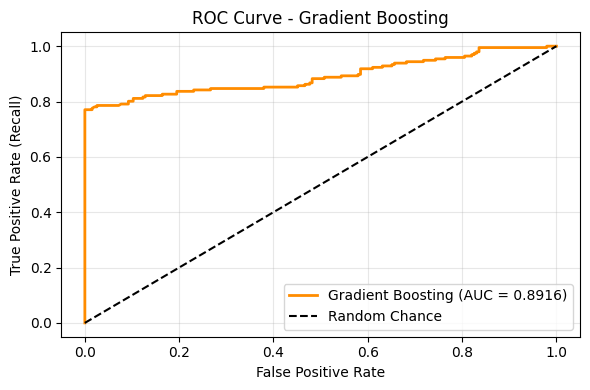

In [118]:


gb_best = gb_grid.best_estimator_
gb_cv_mean = gb_grid.best_score_
gb_cv_std = gb_grid.cv_results_['std_test_score'][gb_grid.best_index_]

y_pred_gb = gb_best.predict(X_test)
y_proba_gb = gb_best.predict_proba(X_test)[:, 1]

gb_acc = accuracy_score(y_test, y_pred_gb)
gb_rec = recall_score(y_test, y_pred_gb, pos_label=1)
gb_prec = precision_score(y_test, y_pred_gb, pos_label=1)
gb_f1 = f1_score(y_test, y_pred_gb, pos_label=1)
gb_auc = roc_auc_score(y_test, y_proba_gb)
gb_gap = gb_cv_mean - gb_acc

print("=" * 45)
print("        GRADIENT BOOSTING EVALUATION        ")
print("=" * 45)
print(f"Mean CV Accuracy   : {gb_cv_mean:.4f} (±{gb_cv_std:.4f})")
print(f"Test Set Accuracy  : {gb_acc:.4f}")
print(f"Generalization Gap : {gb_gap:+.4f}")
print("-" * 45)
print(f"Recall (Sensitivity): {gb_rec:.4f}")
print(f"Precision           : {gb_prec:.4f}")
print(f"F1-Score            : {gb_f1:.4f}")
print(f"ROC-AUC Score       : {gb_auc:.4f}")
print("-" * 45)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

#  Plot ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_gb, tpr_gb, color='darkorange', lw=2, label=f'Gradient Boosting (AUC = {gb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

           XGBOOST EVALUATION               
Mean CV Accuracy   : 0.9168 (±0.0133)
Test Set Accuracy  : 0.8824
Generalization Gap : +0.0345
---------------------------------------------
Recall (Sensitivity): 0.7704
Precision           : 0.9934
F1-Score            : 0.8678
ROC-AUC Score       : 0.8860
---------------------------------------------

Confusion Matrix:
[[194   1]
 [ 45 151]]


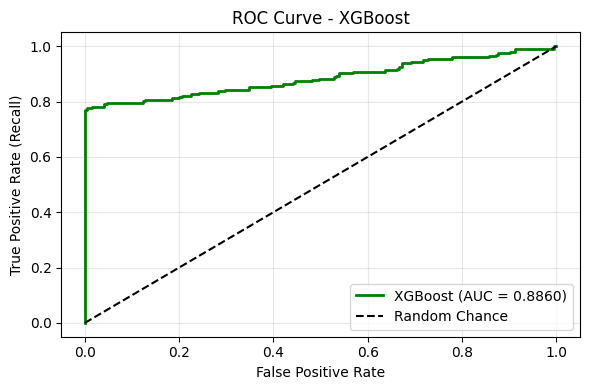

In [119]:
xgb_best = xgb_grid.best_estimator_
xgb_cv_mean = xgb_grid.best_score_
xgb_cv_std = xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]

y_pred_xgb = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb, pos_label=1)
xgb_prec = precision_score(y_test, y_pred_xgb, pos_label=1)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_gap = xgb_cv_mean - xgb_acc

print("=" * 45)
print("           XGBOOST EVALUATION               ")
print("=" * 45)
print(f"Mean CV Accuracy   : {xgb_cv_mean:.4f} (±{xgb_cv_std:.4f})")
print(f"Test Set Accuracy  : {xgb_acc:.4f}")
print(f"Generalization Gap : {xgb_gap:+.4f}")
print("-" * 45)
print(f"Recall (Sensitivity): {xgb_rec:.4f}")
print(f"Precision           : {xgb_prec:.4f}")
print(f"F1-Score            : {xgb_f1:.4f}")
print(f"ROC-AUC Score       : {xgb_auc:.4f}")
print("-" * 45)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# Plot ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Champion Model Selection: Gradient Boosting Classifier

**Selected Model:** `GradientBoostingClassifier`

**Justification:**
Both Gradient Boosting and XGBoost tied on hard test set metrics (88.24% Accuracy, 77.04% Recall, 99.34% Precision). However, **Gradient Boosting** was selected as the final champion model based on two key tie-breakers:
1. **Higher Cross-Validation Score (92.13% vs. 91.81%):** Demonstrates superior average performance across all 5 folds.
2. **Superior ROC-AUC (0.8916 vs. 0.8884):** Indicates better probability calibration and class separability, making it ideal for threshold tuning in medical risk classification.

ROC-AUC evaluates performance across all possible classification thresholds (0.0 to 1.0), not just at 0.5. A higher AUC means Gradient Boosting outputs better-calibrated risk probabilities. Even if both models drew the exact same hard line at 0.5 for the test set, Gradient Boosting was overall more confident and accurate in ordering patients from lowest risk to highest risk.

In [120]:
# Access the best model
best_gb_model = gb_grid.best_estimator_
y_pred = best_gb_model.predict(X_test)

In [121]:
print(best_gb_model)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, random_state=42)


In [122]:
import joblib

In [123]:
joblib.dump(best_gb_model,'gradient_boosting_osteoporosis_model.pkl')

['gradient_boosting_osteoporosis_model.pkl']

In [124]:
print("Model successfully saved as 'gradient_boosting_osteoporosis_model.pkl'")

Model successfully saved as 'gradient_boosting_osteoporosis_model.pkl'


In [125]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']